# LC09 — Time series models: a SARIMA baseline for Svedala, HT27 version (self-paced, ~75 min)

**Which notebook is this:** next year's version of the LC09 notebook, rebuilt after this year's session showed that section 1 and the ARIMA family needed more steps. Section 1 now takes six small steps, and a plain ARMA is fitted before the SARIMA so you see what the seasonal part adds. **If you are taking the course this year, your notebook is `LC09_sarima_baseline.ipynb`** — this one is optional, for Lab 7 preparation; Quiz 3 was set on the original.

Before anyone is allowed to throw machine learning at a forecasting problem (Module 3), they earn the right by building the classical baseline it must beat. This notebook fits a seasonal ARIMA to the Svedala ZON_MITT load and — more importantly — evaluates it the only honest way: **walk-forward, against persistence**. Lab 7 repeats this working method on your own Lab 6 series.

**How to use this notebook:** run the cells top to bottom, one at a time. Every code cell has a note above it saying what it is for and what you should see; the numbers quoted are the ones the course series produces. If what you see differs, stop and ask your pod.

## 0. Before you start: opening the notebook on your laptop

Local, not Colab — it reads the course dataset from the repository. From a terminal with your workbook's venv active (the Lab 1 one; `statsmodels` is in it):

```bash
pip install jupyterlab            # once; the toolbox never imports it, so it is not in requirements.txt
cd <path to your clone of>/course-material/notebooks
jupyter lab                       # opens in your browser; double-click LC09_HT27.ipynb
```

Start Jupyter *inside* `notebooks/` — the guard cell checks that. Shift+Enter runs a cell; the kernel offered, "Python 3 (ipykernel)", is your venv's Python when Jupyter was started from the activated venv.

### 0.1 Setup

`%pip install` installs into the notebook's own Python; in the course venv every one of these is already there at its pinned version, so nothing is upgraded. **What you see:** one "Note: you may need to restart the kernel…" line, or nothing.

In [1]:
# Install exactly what this notebook uses.
%pip install pandas numpy statsmodels matplotlib pyarrow --quiet


Note: you may need to restart the kernel to use updated packages.


The guard: `assert` stops here with a clear message if `../data` is missing. **What you see:** nothing — good.

In [2]:
from pathlib import Path
# Guard: this notebook expects to run from the notebooks/ folder of a clone of
# the course repository — the datasets live one level up in ../data/.
# Failing here, early and clearly, beats a confusing FileNotFoundError later.
assert Path("../data").exists(), (
    "Course data folder not found. Clone KTH-EG2140/course-material and open "
    "this notebook from its notebooks/ folder.")

### 0.2 The series

Line by line:

- The first line holds two statements separated by `;` — Python allows it on one line. `warnings.filterwarnings("ignore")` silences library warnings for the rest of the notebook: statsmodels prints several per fit, and they would bury the outputs you need to read.
- `interpolate(limit=3).dropna()` is LC7's short-gap repair. This column has no gaps, so the line changes nothing — it is the habit, kept.
- `y.asfreq("h")` tells pandas the series is strictly hourly; the models want to know.
- The trailing `;` after `set_ylabel` stops Jupyter from also printing the label object. You will see it after every plot in this notebook.

The timestamps are UTC, one hour behind Swedish winter time. The first run of this cell takes ten seconds or so — pandas and pyarrow loading — and shows nothing while it does.

**What you see:** a year of `ZON_MITT` load in MW — high in winter, low in summer, a fuzzy band because every day has its daily swing.

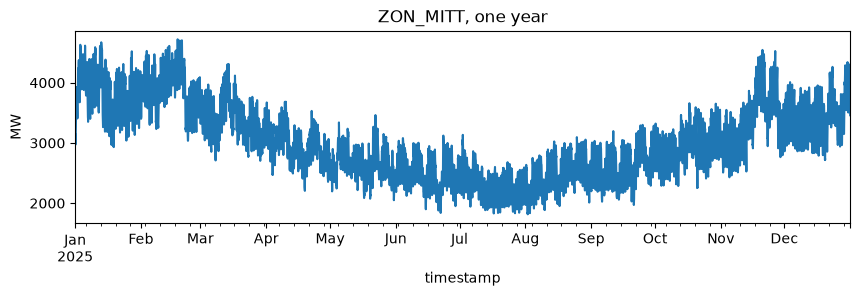

In [3]:
import warnings; warnings.filterwarnings("ignore")   # statsmodels is chatty; see the note above
import numpy as np, pandas as pd
df = pd.read_parquet("../data/svedala-year/svedala_hourly.parquet")
y = df["ZON_MITT"].interpolate(limit=3).dropna()
y = y.asfreq("h")          # tell pandas the series is strictly hourly - the models need to know
ax = y.plot(figsize=(10,2.5), title="ZON_MITT, one year"); ax.set_ylabel("MW");

## 1. Look for structure: ACF and PACF

A load series is nothing but structure — daily cycle, weekly cycle, weather trend. The *autocorrelation function* (ACF) shows it directly: for each lag *k* it gives the correlation between the series and itself shifted by *k* hours, so a value near 1 at lag 24 means "this hour looks like the same hour yesterday".

The section takes six small steps, each a plot and a reading of it:

- 1.1–1.3 look at the raw series: its ACF, the same ACF further out, and its PACF.
- 1.4–1.6 remove the daily cycle, then repeat the ACF and PACF on what is left.
- The end of 1.6 turns the six plots into a model order, and section 3.3 tests it.

Four words used from here on, each made concrete later:

- **stationary**: a series whose level and spread do not drift over time (1.4 shows one);
- **AR** (autoregressive) term: this hour depends on the previous hours' *values*;
- **MA** (moving-average) term: this hour depends on the previous hours' forecast *errors*;
- **SARIMA(p,d,q)(P,D,Q)ₛ**: *p* AR terms, *d* plain differences, *q* MA terms, and capital *P, D, Q* the same three at the seasonal lag *s* — here 24 hours. The name spells Seasonal AutoRegressive Integrated Moving Average; "integrated" refers to the differencing.

### 1.1 The ACF of the raw series, lags 0–72

What it is for: the first look at how strongly each hour resembles the hours before it. `plot_acf(y, lags=72)` draws one bar per lag from 0 to 72 hours (three days). The bar at lag 0 is always 1 — the series compared with itself. The shaded blue band is the range a bar would stay inside if there were no structure at all, so a bar outside it is real. The first run takes about fifteen seconds (statsmodels loading).

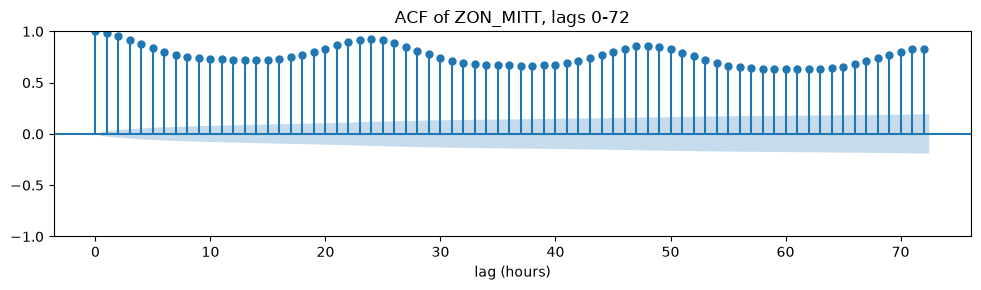

In [4]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
# One panel; plot_acf computes the correlation at every lag 0..72 and draws it as bars
fig, ax = plt.subplots(figsize=(10, 3))
plot_acf(y, lags=72, ax=ax); ax.set_title("ACF of ZON_MITT, lags 0-72")
ax.set_xlabel("lag (hours)")
plt.tight_layout()

**What you see:** every bar is far above zero. The ACF starts at 0.99 at lag 1, sags to about 0.72 around lag 14 (night versus afternoon), climbs back to 0.93 at lag 24, and repeats the wave with peaks at lag 48 (0.86) and lag 72 (0.83).

Two things to read from it:

- **Slow decay** — the peaks shrink only slowly from day to day. The *level* persists: a cold week stays high for days. That is what "not stationary" looks like in an ACF.
- **Peaks at 24 and 48** — the daily cycle. This hour looks most like the same hour yesterday.

The blue band widens with the lag, from about ±0.02 at lag 1 to about ±0.19 at lag 72. statsmodels widens it because, in a series this correlated, a long-lag bar is less certain. Every bar here is still far outside it.

### 1.2 The same ACF out to 200 lags: the weekly cycle

What it is for: a weekly pattern (weekdays versus weekend) lives at lag 168 = 7 × 24, beyond the window of 1.1. Same call, longer reach.

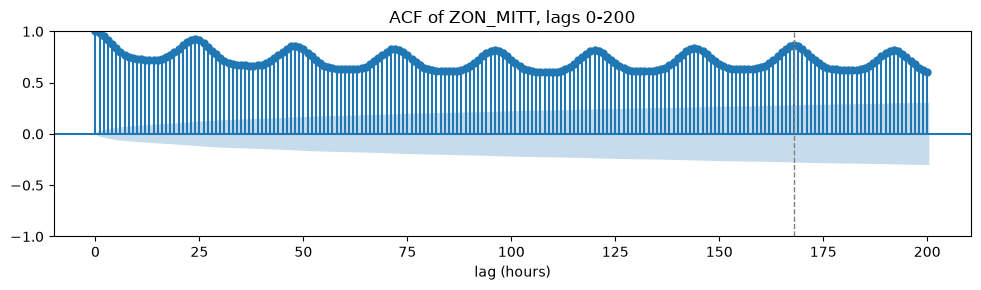

In [5]:
# Same plot, lags 0..200, so lag 168 (one week) is inside the window
fig, ax = plt.subplots(figsize=(10, 3))
plot_acf(y, lags=200, ax=ax); ax.set_title("ACF of ZON_MITT, lags 0-200")
# A dashed line marks one week, to guide the eye
ax.axvline(168, color="grey", ls="--", lw=1); ax.set_xlabel("lag (hours)")
plt.tight_layout()

**What you see:** the daily wave keeps going, and at the dashed line the daily peak is a little taller than its neighbours. Lag 168 reaches 0.86, against 0.84 at lag 144 and 0.82 at lag 192: this hour looks a bit more like the same hour *last week* than the same hour six or eight days ago. That is the weekly cycle.

Why we model the daily cycle first: it is the bigger effect and it repeats every day. The weekly one is a small adjustment on top — the gap between lag 144 and 168 is 0.02. A season of 24 also keeps the model small, and fits in seconds; a season of 168 would make the SARIMA fit far slower. Lab 7's `seasonal_persistence(..., season=168)` baseline is where the weekly cycle gets its own test.

### 1.3 The PACF of the raw series

What it is for: the ACF at lag 24 mixes two things. One is the *direct* effect of yesterday's same hour. The other is the chain hour 1 → hour 2 → … → hour 24, which also makes lag 24 correlated. The *partial* autocorrelation function (PACF) separates them.

- **ACF at lag k**: the plain correlation between now and k hours ago.
- **PACF at lag k**: the correlation that is left after the lags 1 to k−1 are accounted for — the direct effect of lag k alone.

`plot_pacf(y, lags=48, method="ywm")` estimates it. The `"ywm"` method (Yule–Walker) is fast and stable on 8 760 points; the cell runs in a second or two.

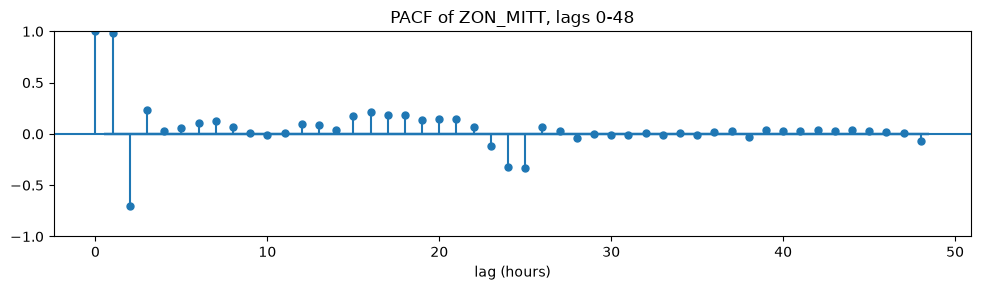

In [6]:
from statsmodels.graphics.tsaplots import plot_pacf
# PACF: the direct effect of each lag, with the shorter lags removed
fig, ax = plt.subplots(figsize=(10, 3))
plot_pacf(y, lags=48, method="ywm", ax=ax); ax.set_title("PACF of ZON_MITT, lags 0-48")
ax.set_xlabel("lag (hours)")
plt.tight_layout()

**What you see:** a very different picture from 1.1.

- **Lag 1** is huge (0.99): the previous hour carries almost all the information. Lag 2 is strongly negative (−0.71) and lag 3 positive (0.24) — corrections to lag 1. After that the bars are small.
- **Lags 15–21** sit at 0.14–0.21: a weak afternoon/evening pattern.
- **Lags 24 and 25** are clear spikes again, both about −0.33. Once the last 23 hours are known, yesterday's same hour still adds information of its own. That is direct evidence of the daily seasonality.

The band here is fixed at ±0.02 — so thin that it hides behind the zero line. Any bar you can see standing out from the line is outside it.

As a hint for the model: a PACF that is large for the first few lags and then dies out points to a small autoregressive (AR) order. The spikes at the seasonal lag point to a seasonal term. We read this properly in 1.6, after removing the daily cycle.

### 1.4 Seasonal differencing: what the transformation does

What it is for: removing the daily cycle and the slowly moving level before modelling what is left. `y.diff(24)` is each hour minus the same hour the day before — the *seasonal difference*. The first 24 hours have no "yesterday" and come out as NaN; `.dropna()` removes them. Before looking at its ACF, look at the differenced series itself. The cell plots one January week, raw on the left and differenced on the right.

raw series: mean 3056 MW, std 621 MW
diff(24):   mean 1 MW, std 233 MW


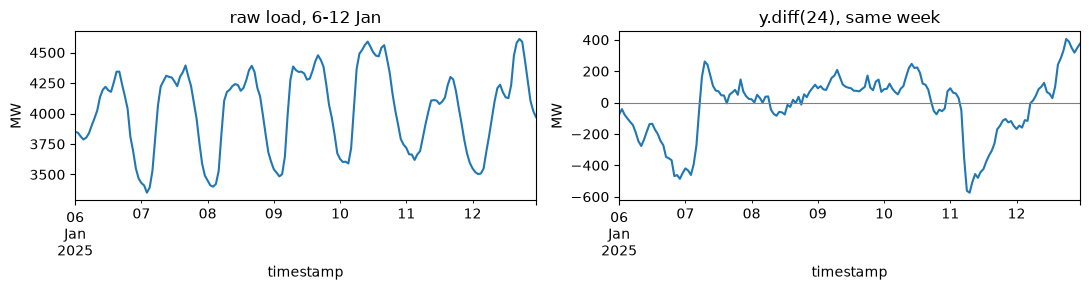

In [7]:
# Seasonal difference: this hour minus the same hour yesterday
d24 = y.diff(24).dropna()
# Two panels, the same January week before and after differencing
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
y.loc["2025-01-06":"2025-01-12"].plot(ax=ax[0]); ax[0].set_title("raw load, 6-12 Jan"); ax[0].set_ylabel("MW")
d24.loc["2025-01-06":"2025-01-12"].plot(ax=ax[1]); ax[1].set_title("y.diff(24), same week"); ax[1].set_ylabel("MW")
ax[1].axhline(0, color="grey", lw=0.8)   # zero = 'same as yesterday'
plt.tight_layout()
# Summary numbers for the whole year, before and after
print(f"raw series: mean {y.mean():.0f} MW, std {y.std():.0f} MW")
print(f"diff(24):   mean {d24.mean():.0f} MW, std {d24.std():.0f} MW")

**What you see:** on the left, the familiar daily waves on top of a level that drifts through the week. On the right, the regular daily wave is gone. What remains moves in slower swings of a day or so, around zero, between about −570 and +400 MW this week: a value of +300 means "300 MW more than this hour yesterday". The deep dip on the 11th is a Saturday compared with a Friday — the weekly cycle of 1.2 that a 24-hour difference does not remove. (The timestamps are UTC: the Saturday-versus-Friday comparison begins at 23:00 UTC on the 10th, Swedish midnight. The dip itself opens around 05:00 UTC, where Friday's morning rise has no Saturday match.)

Over the whole year the mean drops from about 3 060 MW to about 1 MW, and the spread (standard deviation) from 621 to 233 MW.

This is what *stationary* means here: the differenced series has no daily wave and no drifting level. It moves around one fixed mean with a roughly constant spread, so what is learnt from January applies to February. A model is much easier to fit to that than to the raw series. It is also why SARIMA does the subtraction itself — the D = 1 in section 2.

### 1.5 The ACF of the differenced series

What it is for: checking what structure is left once the daily cycle is removed. Same call as 1.1, on `d24`.

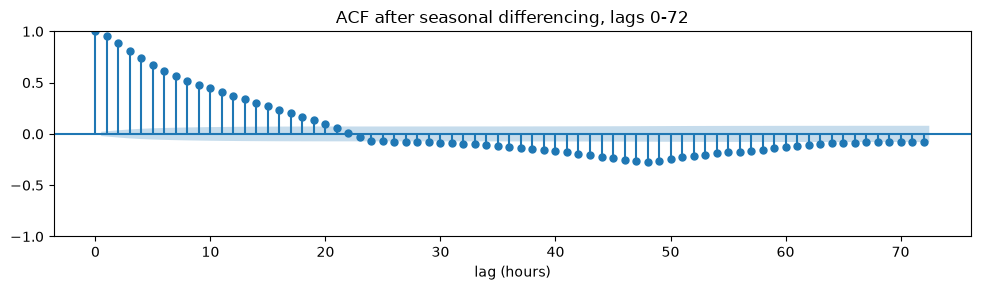

In [8]:
# ACF of what is left after subtracting yesterday
fig, ax = plt.subplots(figsize=(10, 3))
plot_acf(d24, lags=72, ax=ax); ax.set_title("ACF after seasonal differencing, lags 0-72")
ax.set_xlabel("lag (hours)")
plt.tight_layout()

**What you see:** the daily peaks are gone.

- **Lags 1–22**: the bars start high (0.96 at lag 1) and fall almost in a straight line to zero around lag 22. The differenced series still resembles its own recent past, hour to hour: a cold morning tends to stay colder than yesterday all day.
- **Lags 23–72**: the bars go *negative*, a broad bowl with its bottom at lag 48 (about −0.27). The bowl is the subtraction's own footprint. If today was unusually high, today − yesterday is high; tomorrow − today then tends to be low, because today's high value enters it with a minus sign. So differenced values a day or more apart lean in opposite directions — and because a cold or warm spell usually lasts a day or two, the deepest point comes two days out, at lag 48.

What is left to model is the short-range part — the first twenty or so lags. That is what the AR and MA terms of section 2 do.

### 1.6 The PACF of the differenced series, and the choice of model

What it is for: the direct effects left in the differenced series. They suggest the remaining orders.

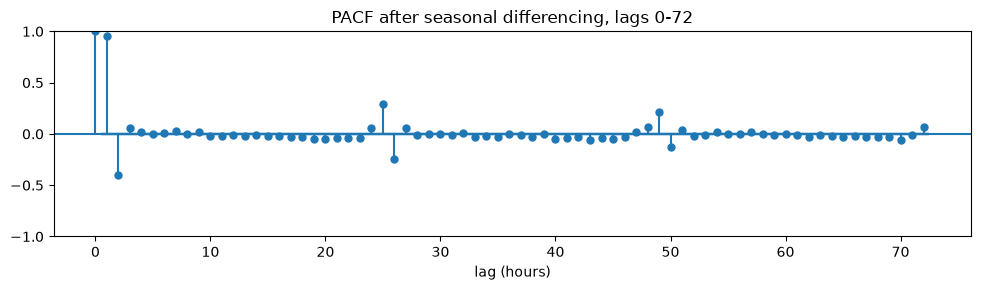

In [9]:
# PACF of the differenced series: the direct effects that are left
fig, ax = plt.subplots(figsize=(10, 3))
plot_pacf(d24, lags=72, method="ywm", ax=ax); ax.set_title("PACF after seasonal differencing, lags 0-72")
ax.set_xlabel("lag (hours)")
plt.tight_layout()

**What you see:**

- **Short range**: lag 1 is large (0.96) and lag 2 negative (−0.40). From lag 3 on the bars are small (0.06 at lag 3, under 0.06 after that, though a few creep just outside the very thin band) up to lag 23 — the PACF *cuts off* after lag 2.
- **Seasonal lags**: spikes return just past each day — +0.29 at lag 25 and −0.24 at lag 26, then +0.21 at lag 49 and −0.13 at lag 50, shrinking each day.

Reading the six plots as a recipe:

- **D = 1, s = 24**: one seasonal difference. 1.4 and 1.5 showed that subtracting yesterday removes the daily wave and the drifting level.
- **d = 0**: no further plain difference. After `diff(24)` the ACF no longer stays near 0.9 for days as in 1.1; it crosses zero within a day and stays within about ±0.3. The level no longer drifts.
- **Short range**: a PACF that cuts off after lag 2, with an ACF that fades gradually (1.5), is the textbook signature of **AR(2)**: p = 2, q = 0.
- **Seasonal part**: spikes at 25 and 26 rather than 24 are what a short-range term and a seasonal term produce *together* — lag 1 plus lag 24 is lag 25. SARIMA multiplies its two parts, so terms at lag 24 also cover these cross-lags. One seasonal term of each kind, P = 1 and Q = 1, is the usual start.

So the plots suggest **SARIMA(2,0,0)(1,1,1)₂₄**. The model this notebook fits — the one the original LC09 uses — is **(1,0,1)(1,1,1)₂₄**: one AR and one MA term instead of two AR terms. It has the same number of short-range coefficients, and a mixed model can imitate an AR(2).

Which is better? The plots cannot say. Section 3.3 fits both and scores them two ways:

- **AIC**, an *information criterion*: how well a model fits its training data, with a penalty for every extra coefficient;
- **the walk-forward test**: how well it *forecasts*.

They will disagree — and that disagreement is why Lab 7 decides with the harness.

## 2. Fit — on six weeks, honestly split

Never fit on data you will evaluate on. Train: six winter weeks. Test: the week after. The section fits two models on the same six weeks:

- 2.2 fits a plain ARMA, with no seasonal part.
- 2.3 adds the seasonal part, which makes it the SARIMA.

Comparing the two shows what the seasonal part buys.

### 2.1 The split

`train` and `test` are date-string slices, both ends included, as in LC6: six weeks of winter, then one week. **What you see:** `train 984 h, test 168 h` (41 days × 24 and 7 × 24).

In [10]:
# Temporal split: fit on the first six weeks, judge on the week after
train = y.loc["2025-01-06":"2025-02-15"]
test  = y.loc["2025-02-16":"2025-02-22"]
print(f"train {len(train)} h, test {len(test)} h")

train 984 h, test 168 h


### 2.2 ARMA first: a model without the daily cycle

What it is for: the simplest model of section 1's short-range structure, fitted before anything seasonal, to see what it can and cannot do. ARMA(1,1) — "ARMA" is just AR and MA together; in SARIMAX's notation `order=(1,0,1)` — has two parts:

- **AR(1)**, the autoregressive term: this hour = a constant + φ × the previous hour. It captures "the level persists".
- **MA(1)**, the moving-average term: plus θ × the previous hour's *forecast error*. It captures a short correction after a surprise.

`trend="c"` adds the constant, so the model can sit at a level of thousands of MW instead of being pulled towards zero. `fit(disp=False, maxiter=500)` estimates φ, θ, the constant and the noise variance. `maxiter=500` lets the optimiser take more steps: with the default 50 it stops before it has converged on this series. The fit takes under a second.

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
# ARMA(1,1) with a constant, on the raw training weeks - no differencing, no season
arma = SARIMAX(train, order=(1, 0, 1), trend="c").fit(disp=False, maxiter=500)

`arma.params` holds the estimated coefficients by name. `.round(3)` keeps three decimals; `arma.aic` is the information criterion of 1.6 (lower is better, and only comparable between models fitted on the same data). **What you see:** `intercept` 265.5, `ar.L1` 0.932 (φ), `ma.L1` 0.709 (θ), `sigma2` 6 654 (the variance of the one-hour-ahead error, in MW²), and AIC 11 466.

The intercept is not the level itself. An AR(1) settles where level = intercept + φ × level, that is at intercept / (1 − φ) = 265.5 / 0.068 ≈ 3 900 MW — the training mean, where the forecast below goes flat.

In [12]:
# The four estimated numbers, and the AIC that 2.3 compares with SARIMA's
print(arma.params.round(3).to_string())
print(f"AIC {arma.aic:.0f}")

intercept     265.492
ar.L1           0.932
ma.L1           0.709
sigma2       6653.736
AIC 11466


What it is for: the forecast from the end of the training window (15 Feb, 23:00) for the next 48 hours, against what really happened. `arma.forecast(48)` returns 48 hourly values on the right timestamps. The plot starts three days before the forecast so the daily shape is visible.

48 h MAE: ARMA 295 MW


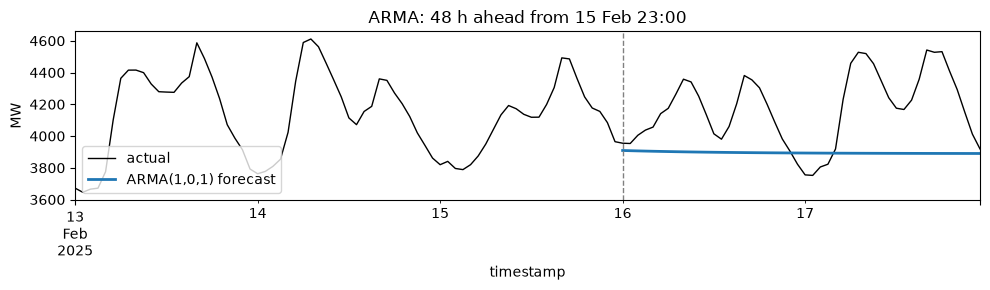

In [13]:
# 48 h ahead from the last training hour
fc_arma = arma.forecast(48)
# The real 48 hours, for comparison
actual48 = y.loc[fc_arma.index[0] : fc_arma.index[-1]]
# Plot: the last three training days (72 h) plus the 48 h after, then the forecast on top
ax = y.loc[train.index[-72] : actual48.index[-1]].plot(figsize=(10, 3), label="actual", color="black", lw=1)
fc_arma.plot(ax=ax, label="ARMA(1,0,1) forecast", lw=2)
ax.axvline(test.index[0], color="grey", ls="--", lw=1)   # end of training data
ax.legend(loc="lower left"); ax.set_ylabel("MW"); ax.set_title("ARMA: 48 h ahead from 15 Feb 23:00")
plt.tight_layout()
print(f"48 h MAE: ARMA {(fc_arma - actual48).abs().mean():.0f} MW")

**What you see:** the forecast starts near the last observed value and goes **flat** within hours, at about 3 890 MW — the training mean. The actual load swings by 550–800 MW each day. Averaged over the 48 hours, the miss is about 295 MW.

Why it goes flat:

- The AR part pulls each step towards the mean. After *k* hours only φᵏ of the starting gap is left: 0.932⁶ ≈ 0.66 after six hours, and 0.932²⁴ ≈ 0.18 after a day.
- The MA part only reacts to the *last* error, which is unknown one step into the future, so it adds nothing beyond the first hour.
- ARMA assumes the series is stationary, and it has no seasonal term. Nothing in the model knows that 08:00 is different from 03:00.

Section 3 walks this model forward over the test week. It scores **301 MW**, worse than persistence ("tomorrow = today", 203 MW). The daily cycle has to be in the model.

### 2.3 Add the seasonal part: SARIMA

The same call with one argument added, `seasonal_order=(1,1,1,24)`. This adds the three seasonal terms at lag 24 that 1.6 suggested:

- **D = 1**: the model takes the `diff(24)` of section 1.4 itself, so it works on "change from yesterday".
- **P = 1**: a seasonal AR term (yesterday's same hour).
- **Q = 1**: a seasonal MA term (yesterday's same-hour error).

(The letters are the ones defined at the start of section 1.) statsmodels' class is called `SARIMAX`: the X stands for eXogenous inputs — extra columns such as temperature. This notebook uses none.

The two `enforce_*=False` flags relax two conditions the estimator otherwise insists on: that the fitted AR part is stationary, and that the fitted MA part is *invertible* (its memory of past errors fades rather than grows). On a short window the fit is better behaved without them, and the forecasts are what we judge it by. `model.fit(disp=False)` estimates the coefficients without a progress printout; `fit.summary().tables[0]` shows the first table of the summary only.

**What you see:** a table whose lines to read are:

- `Dep. Variable: ZON_MITT`
- `No. Observations: 984` (41 days × 24 hours)
- `Model: SARIMAX(1, 0, 1)x(1, 1, 1, 24)`

The rest (log likelihood, `Covariance Type: opg`, …) is fit bookkeeping; its AIC line is compared with ARMA's in the next cell. The fit takes a few seconds.

In [14]:
# The same model class as 2.2, now with the seasonal part at lag 24
model = SARIMAX(train, order=(1,0,1), seasonal_order=(1,1,1,24),
                enforce_stationarity=False, enforce_invertibility=False)
fit = model.fit(disp=False)
print(fit.summary().tables[0])

                                     SARIMAX Results                                      
Dep. Variable:                           ZON_MITT   No. Observations:                  984
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood               -4944.651
Date:                            Thu, 01 Oct 2026   AIC                           9899.301
Time:                                    20:40:26   BIC                           9923.499
Sample:                                01-06-2025   HQIC                          9908.529
                                     - 02-15-2025                                         
Covariance Type:                              opg                                         


What it is for: the two fits side by side, on the same 48 hours. The table puts the coefficients of both models in one frame; a coefficient a model does not have shows as NaN. **What you see:**

- SARIMA keeps a strong AR term (`ar.L1` 0.959) and a weaker MA term (`ma.L1` 0.462), and adds the seasonal ones: `ar.S.L24` is small (0.078), `ma.S.L24` is large (−0.919).
- `sigma2` — the one-hour-ahead error variance — falls from 6 654 to 2 234 MW², about a third.
- AIC falls from 11 466 to 9 899. Lower is better, so the training-fit score agrees with the plot. (Strictly, these two AICs are not comparable: SARIMA's is computed on the differenced series and skips its first 50 hours. `sigma2` and the 48 h MAE are the fair comparison here, and section 3 decides. In 3.3 both candidates have the same seasonal difference, so their AICs do compare.)
- In the plot, SARIMA follows the daily shape — the morning rise, the evening fall — where ARMA is flat. Its 48-hour MAE is about 134 MW against ARMA's 295.

               ARMA    SARIMA
ar.L1         0.932     0.959
ar.S.L24        NaN     0.078
intercept   265.492       NaN
ma.L1         0.709     0.462
ma.S.L24        NaN    -0.919
sigma2     6653.736  2233.897
AIC: ARMA 11466   SARIMA 9899
48 h MAE: ARMA 295 MW   SARIMA 134 MW


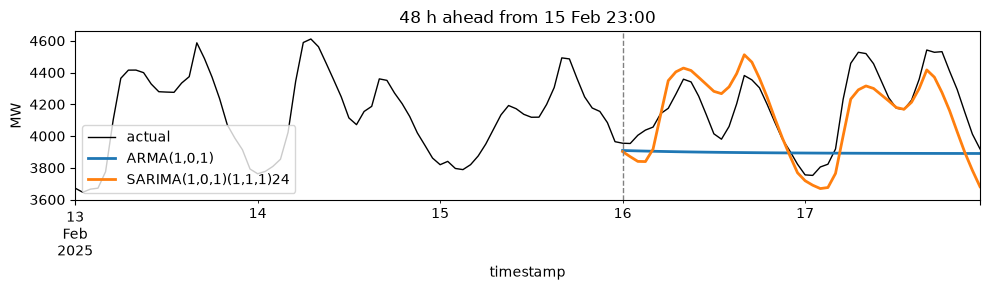

In [15]:
# Coefficients of both models in one table (NaN = the model has no such term)
print(pd.DataFrame({"ARMA": arma.params, "SARIMA": fit.params}).round(3).to_string())
print(f"AIC: ARMA {arma.aic:.0f}   SARIMA {fit.aic:.0f}")
# Both 48 h forecasts on the same axis
fc_sarima = fit.forecast(48)
ax = y.loc[train.index[-72] : actual48.index[-1]].plot(figsize=(10, 3), label="actual", color="black", lw=1)
fc_arma.plot(ax=ax, label="ARMA(1,0,1)", lw=2)
fc_sarima.plot(ax=ax, label="SARIMA(1,0,1)(1,1,1)24", lw=2)
ax.axvline(test.index[0], color="grey", ls="--", lw=1)
ax.legend(loc="lower left"); ax.set_ylabel("MW"); ax.set_title("48 h ahead from 15 Feb 23:00")
plt.tight_layout()
print(f"48 h MAE: ARMA {(fc_arma - actual48).abs().mean():.0f} MW   SARIMA {(fc_sarima - actual48).abs().mean():.0f} MW")

## 3. Evaluate like an operator: walk-forward, 24 h ahead

An operator forecasts tomorrow every day, learning nothing from the future. Simulate exactly that: for each test day, forecast 24 h ahead, then reveal that day and continue. And always alongside the humblest competitor there is — **persistence**: "tomorrow = today".

### 3.1 The loop, and the four numbers

`pd.date_range(test.index[0], test.index[-1], freq="24h")` steps through the test week one day at a time. For each day the loop:

- forecasts the next 24 hours from everything the model has seen: `state.forecast(horizon)`;
- takes the real day, `chunk = y.loc[day : day + pd.Timedelta(hours=horizon-1)]` — both ends included, so 24 hours;
- trims the forecast to the day's length, `fc.values[:len(chunk)]` (a guard for a series that ends mid-day), and puts it on the real hours' index so the two can be subtracted;
- records the two baselines on the same hours: `y.shift(24)` is persistence (tomorrow = today), `y.shift(168)` seasonal persistence (this Tuesday = last Tuesday);
- *reveals* the day with `state.append(chunk)`: the model's state moves forward without re-estimating its coefficients.

The ARMA of 2.2 goes through the same steps (`arma_state`), so it gets a fourth number on exactly the same days. After the loop, `pd.concat` glues the seven days back into one series each.

The scores:

- **MAE** is the mean absolute error, the average size of the miss in MW.
- **Skill** is `1 − MAE / MAE_baseline` against whichever baseline is harder to beat — the one with the smaller MAE, hence `min(...)`. `{...:+.0f}` prints the sign, so a skill reads `+23%` or `-5%`.

These walk-forward numbers are *the* result. The 48-hour MAEs of section 2 were one look from one starting point; this is seven days, each forecast the way an operator would.

One honesty note on `append`: it is a fast approximation of what Lab 7's `walk_forward` does, which *refits* the model each day on the longer training window. Here the two agree to within a megawatt (156 vs 155 MW on this week); on other series they can differ more, and the refit is the honest number.

**What you see:**

```
walk-forward MAE, 24 h ahead:  SARIMA 156 MW   persistence 203 MW   seasonal persistence 283 MW
skill vs the better baseline: +23%
ARMA(1,0,1), no seasonal part: 301 MW
```

ARMA loses even to persistence: without the daily cycle, a model with fitted coefficients does worse than copying yesterday.

The weekly baseline *loses* to the daily one this week: from one week to the next the weather moved more than the weekly shape is worth. In the plot below, the seasonal-persistence line sits about 400 MW below the actual on Sunday the 16th, a hundred or so below on the 17th and 18th, and 600 MW above on Saturday the 22nd. That is not a rule — on other weeks it flips — which is why Lab 7 asks for both, every time.

In [16]:
horizon = 24
preds, persist, weekly, actual = [], [], [], []
state = fit
preds_arma = []           # the ARMA of 2.2, walked forward the same way
arma_state = arma
# Walk-forward loop: for each test day, forecast 24 h ahead from what is known,
# THEN reveal that day (state.append) so the next iteration may use it.
# .append updates the model state with new data without refitting parameters —
# cheap, and exactly what an operator's system does overnight.
for day in pd.date_range(test.index[0], test.index[-1], freq="24h"):
    fc = state.forecast(horizon)
    chunk = y.loc[day : day + pd.Timedelta(hours=horizon-1)]
    preds.append(pd.Series(fc.values[:len(chunk)], index=chunk.index))
    fc_a = arma_state.forecast(horizon)                  # ARMA's forecast for the same day
    preds_arma.append(pd.Series(fc_a.values[:len(chunk)], index=chunk.index))
    persist.append(y.shift(24).loc[chunk.index])         # persistence: tomorrow = today
    weekly.append(y.shift(168).loc[chunk.index])         # seasonal persistence: this Tuesday = last Tuesday
    actual.append(chunk)
    state = state.append(chunk)          # reveal the day, don't refit
    arma_state = arma_state.append(chunk)
# The seven days glued back into one series each
pred = pd.concat(preds); pers = pd.concat(persist); week = pd.concat(weekly); act = pd.concat(actual)
# MAE = mean absolute error: the average size of the miss, in MW
mae_s = (pred - act).abs().mean(); mae_p = (pers - act).abs().mean(); mae_w = (week - act).abs().mean()
print(f"walk-forward MAE, 24 h ahead:  SARIMA {mae_s:.0f} MW   persistence {mae_p:.0f} MW   seasonal persistence {mae_w:.0f} MW")
better = min(mae_p, mae_w)             # the baseline that matters is the one that is harder to beat
print(f"skill vs the better baseline: {100*(1-mae_s/better):+.0f}%")
mae_a = (pd.concat(preds_arma) - act).abs().mean()
print(f"ARMA(1,0,1), no seasonal part: {mae_a:.0f} MW")

walk-forward MAE, 24 h ahead:  SARIMA 156 MW   persistence 203 MW   seasonal persistence 283 MW
skill vs the better baseline: +23%
ARMA(1,0,1), no seasonal part: 301 MW


### 3.2 Look at it

Four lines on one axis: actual, SARIMA, and the two baselines drawn fainter (`alpha=0.5`). **What you see:** SARIMA has the daily shape right but not the amplitude — it undershoots the afternoon peaks by one to two hundred MW mid-week and sits three to five hundred MW too high on Saturday the 22nd, its worst day; persistence is the actual shifted right by a day; seasonal persistence is visibly off where this week differs from last. A 156 MW average miss looks like this — keep the picture in mind when a skill number sounds good.

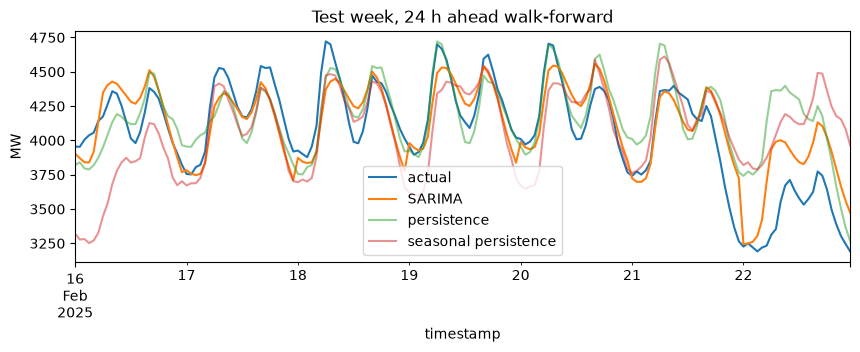

In [17]:
# Actual, SARIMA and the two baselines on the test week; baselines drawn fainter
ax = act.plot(figsize=(10,3), label="actual")
pred.plot(ax=ax, label="SARIMA"); pers.plot(ax=ax, label="persistence", alpha=0.5); week.plot(ax=ax, label="seasonal persistence", alpha=0.5)
ax.legend(); ax.set_title("Test week, 24 h ahead walk-forward"); ax.set_ylabel("MW");

Read the skill number, not the plot: a model that cannot beat "tomorrow = today" has learned nothing worth deploying — and on calm weeks persistence is *hard* to beat. This number is the bar every Module 3 learner must clear, on exactly this evaluation. The things SARIMA cannot see — temperature swings, holidays — are precisely where covariates (extra input columns, such as temperature) and learned models will earn their keep.


### 3.3 The order the plots suggested

What it is for: settling 1.6's question with numbers. The cell fits SARIMA(2,0,0)(1,1,1)₂₄ — the order the PACF pointed to — on the same six weeks, and walks both candidates forward over the same test week. `walk_mae(model_fit)` is the loop of 3.1 packed into a small function: `def` gives a block of code a name, so it can be run once per model. It takes a few seconds.

**What you see:**

```
                     AIC   walk-forward MAE
(1,0,1)(1,1,1)24    9899   156.1 MW
(2,0,0)(1,1,1)24    9863   168.5 MW
```

The plots' choice fits the training weeks *better* (lower AIC) and forecasts the test week *worse* (about 12 MW more). That is this notebook's lesson in one table: ACF and PACF suggest candidates, AIC scores the fit to the past, and only a walk-forward test tells you how a model forecasts. Lab 7's harness is built for exactly that decision.

In [18]:
# The order the PACF pointed to, fitted on the same six weeks
fit_ar2 = SARIMAX(train, order=(2, 0, 0), seasonal_order=(1, 1, 1, 24),
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

def walk_mae(model_fit):
    """Walk-forward MAE over the test week, 24 h ahead, as in 3.1."""
    preds = []
    state = model_fit
    # One test day at a time: forecast it, then reveal it
    for day in pd.date_range(test.index[0], test.index[-1], freq="24h"):
        fc = state.forecast(24)
        chunk = y.loc[day : day + pd.Timedelta(hours=23)]
        preds.append(pd.Series(fc.values[:len(chunk)], index=chunk.index))
        state = state.append(chunk)
    # The seven days as one series, scored against the same actual hours as 3.1
    return (pd.concat(preds) - act).abs().mean()

# Both candidates: the training-fit score and the forecast score
print(f"{'':18s} {'AIC':>5s}   walk-forward MAE")
print(f"{'(1,0,1)(1,1,1)24':18s} {fit.aic:5.0f}   {walk_mae(fit):.1f} MW")
print(f"{'(2,0,0)(1,1,1)24':18s} {fit_ar2.aic:5.0f}   {walk_mae(fit_ar2):.1f} MW")

                     AIC   walk-forward MAE


(1,0,1)(1,1,1)24    9899   156.1 MW


(2,0,0)(1,1,1)24    9863   168.5 MW


## Self-check


Two promises: SARIMA beats both baselines, and its 24-hour MAE is under 10 % of the mean load. **What you see:** `ALL OK — baseline set: SARIMA 156 MW vs persistence 203 / seasonal 283 MW. Lab 7 makes this yours.`

In [19]:
assert mae_s < min(mae_p, mae_w), "SARIMA should beat both baselines on this winter week"
assert mae_s < 0.10 * act.mean(), "24h MAE above 10% of mean load — something is off"
print(f"ALL OK — baseline set: SARIMA {mae_s:.0f} MW vs persistence {mae_p:.0f} / seasonal {mae_w:.0f} MW. Lab 7 makes this yours.")

ALL OK — baseline set: SARIMA 156 MW vs persistence 203 / seasonal 283 MW. Lab 7 makes this yours.


## 4. What you take to Lab 7

Lab 7 asks for this working method as toolbox code: `persistence(y, horizon=24)` and `seasonal_persistence(y, horizon=24, season=168)` are one `shift` each; `walk_forward(y, model_fn, test_start, test_end, horizon=24)` is the loop above with a refit per day and a `model_fn` you pass in — any function of the form `model_fn(train, horizon) -> the next horizon values`, so the same *harness* (the fixed evaluation set-up) later judges every Module 3 learner. All three go into `src/svedala_toolbox/evaluation.py`, where the stubs wait. The deliverable is the number and the honest sentence around it: all three MAEs, and skill against the *better* baseline.